In [80]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [130]:
import math

In [200]:
class value:
    def __init__(self,value, _children=(), _op='', label=''):
        self.data = value
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None
        self.label = label
    
    def __add__(self,other):
        self.grad = 0.0
        other.grad = 0.0
        out = value(self.data + other.data, _children=(self, other), _op='+')
        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    
    def __mul__(self,other):
        self.grad = 0.0
        other.grad = 0.0
        out = value(self.data * other.data, _children=(self, other), _op='*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    
    def __repr__(self):
        return f"value({self.data})"
    
    def tanh(self):
        self.grad = 0.0
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)

        out = value(t, _children=(self,), _op='tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):

        self.grad = 1.0
        print(self.grad, self.label)
        topo = []
        visited = set()
        def build_topo(v):
            if v != None and v not in visited:
                # print(v.label)
                visited.add(v)
                for child in v._prev:
                    build_topo(child)#dfs

                print(v.label)
                topo.append(v)

        topo = build_topo(self)
        # topo = topo[::-1]
        for node in topo:
            print(node.label)
            # node._backward()

In [82]:
a = value(10, label='a')
b = value(2, label='b')
c = value(5, label='c')
d = a * b
d.label = 'd'
e = c + d
e.label = 'e'
f = value(3, label='f')
g = e * f
g.label = 'g'

In [83]:
g._prev

{value(25), value(3)}

In [84]:
g._op

'*'

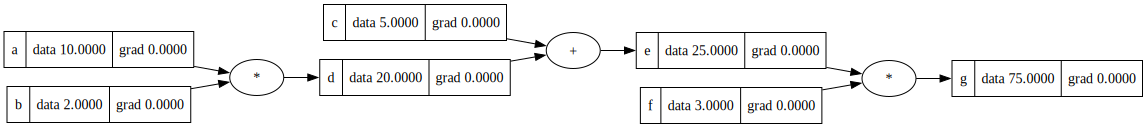

In [85]:
draw_dot(g)

In [117]:
def lol():

    h = 0.0001
    a = value(10, label='a')
    b = value(2, label='b')
    c = value(5, label='c')
    d = a * b
    d.label = 'd'
    e = c + d
    e.label = 'e'
    f = value(3, label='f')
    g1 = e * f
    g1.label = 'g1'

    a = value(10, label='a')
    b = value(2, label='b')
    c = value(5, label='c')
    # a.data += h
    # b.data += h
    # c.data += h
    d = a * b
    d.label = 'd'
    # d.data += h
    e = c + d
    e.label = 'e'
    f = value(3, label='f')
    e.data += h
    # f.data += h
    g2 = e * f
    g2.label = 'g2'
    # g2 += h

    print((g2.data - g1.data) / h)
    return (g2.data - g1.data) / h

In [93]:
#g
lol()
g.grad = 1.0

1.0000000000331966


In [96]:
#f
lol()
f.grad = 25


25.00000000011937


In [118]:
#e
e.grad = lol()

2.999999999957481


In [110]:
#d
d.grad = lol()

2.999999999957481


In [108]:
#c
c.grad = lol()

2.999999999957481


In [112]:
#b
b.grad = lol()

30.000000000001137


In [114]:
#a
a.grad = lol()

5.999999999914962


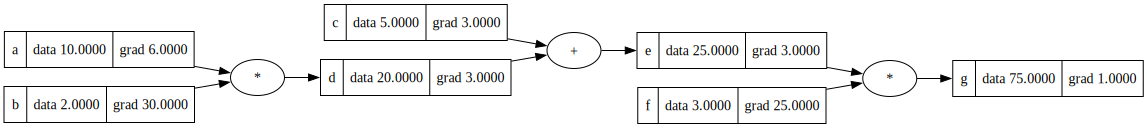

In [119]:
draw_dot(g)

In [116]:
print(g.grad)
print(f.grad)
print(e.grad)
print(d.grad)
print(c.grad)
print(b.grad)
print(a.grad)

1.0
25
None
2.999999999957481
2.999999999957481
30.000000000001137
5.999999999914962


In [120]:
print(g.grad)
print(f.grad)
print(e.grad)
print(d.grad)
print(c.grad)
print(b.grad)
print(a.grad)

1.0
25
2.999999999957481
2.999999999957481
2.999999999957481
30.000000000001137
5.999999999914962


In [127]:
a.data -= 0.001*a.grad
b.data -= 0.001*b.grad
c.data -= 0.001*c.grad
f.data -= 0.001*f.grad

In [128]:
d = a * b
e = c + d
g1 = e * f
print(g,g1)    

value(75) value(71.89362400000117)


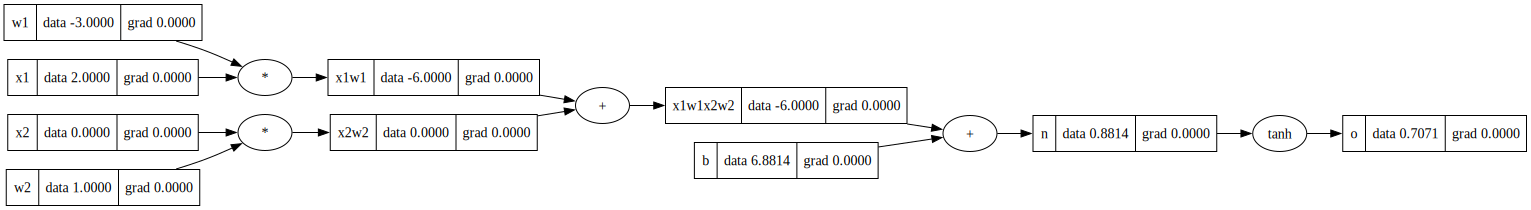

In [145]:
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2') 

w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

b = value(6.881373587019543, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

In [146]:
o.grad = 1.0

In [147]:
n.grad = o.grad * (1 - o.data ** 2)

In [148]:
print(n.grad)

0.4999999999999999


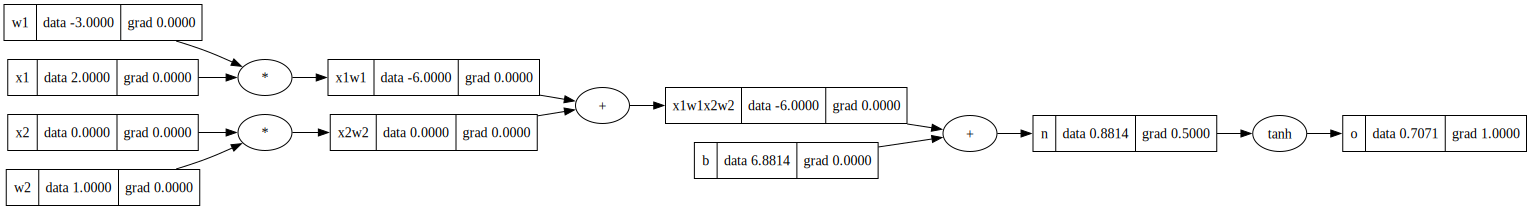

In [149]:
draw_dot(o)

In [152]:
x1w1x2w2.grad = n.grad
b.grad = n.grad

x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

x1.grad = x1w1.grad * w1.data
w1.grad = x1w1.grad * x1.data

x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data



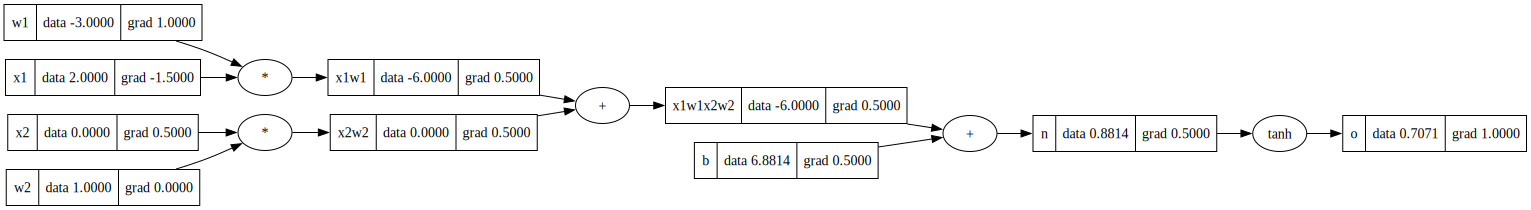

In [153]:
draw_dot(o)

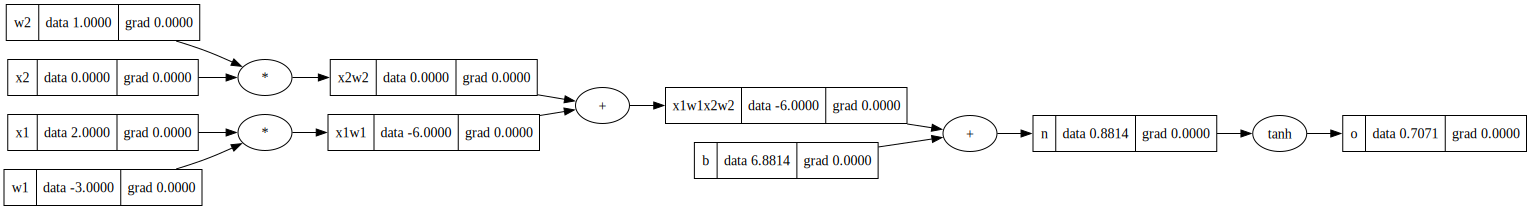

In [193]:
x1 = value(2.0, label='x1')
x2 = value(0.0, label='x2') 

w1 = value(-3.0, label='w1')
w2 = value(1.0, label='w2')

b = value(6.881373587019543, label='b')

x1w1 = w1 * x1; x1w1.label = 'x1w1'
x2w2 = w2 * x2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

In [201]:
# o.grad = 1.0
# o._backward()
# n._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()

o.backward()

# draw_dot(o)

w2
x2
x2w2
x1
w1
x1w1
x1w1x2w2
b
n
o


TypeError: 'NoneType' object is not subscriptable

In [190]:
topo = []

visited = set()
def build_topo(v):
    if v != None and v not in visited:
        # print(v.label)
        visited.add(v)
        for child in v._prev:
            build_topo(child)#dfs

        # print(v.label)
        topo.append(v)

build_topo(o)
topo = topo[::-1]
o.grad = 1.0
for node in topo:
    node._backward()
    print(node.label)

o
n
x1w1x2w2
x2w2
x2
w2
x1w1
x1
w1
b


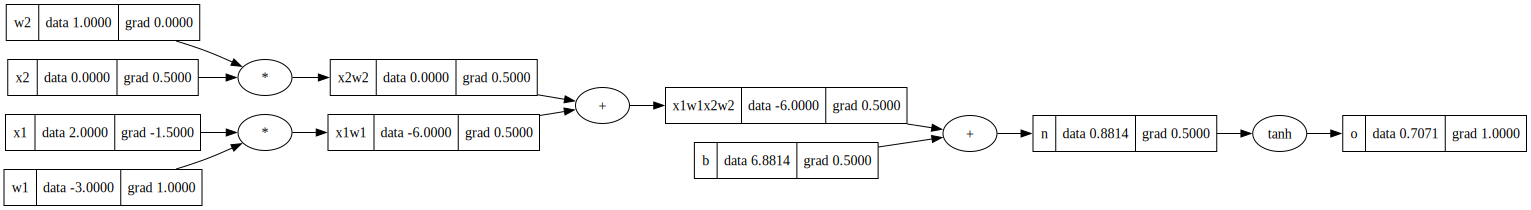

In [191]:
draw_dot(o)